# Personal Information
Name: **Jia Long Bao**

StudentID: **12593400**

Email: [**jialong.bao@student.uva.nl**](jialong.bao@student.uva.nl)

Submitted on: **XX.10.2025**

TODO: look into jonathan's duckdb to work with entire services dataset?

# Data Context
**In this section you should introduce the datasources and datasets which you will be working with. Explain where they are from as well as their domain. Give an overview of what the context of the data is. You should not spend more than 1 to 2 paragraphs here as the core information will be in the next section.**

The data used in this research originates from Rijden De Treinen, capturing spatial, temporal, and reported causes that influence train delays in the Netherlands. 

The spatial data, which includes (station locations and) railway connections, is extracted from (the NS API and) Rijden de Treinen, a platform that processes real-time open data from NDOV (Nationale Data Openbaar Vervoer). This ensures an accurate representation of the railway network, which forms the foundation of modeling the graph structure. Additionally, annual passenger volume per station, retrieved from the NS dashboard, provides insights into station-level demand.

The temporal data consists of train service schedules, recorded delays and disruptions all sourced from Rijden de Treinen.

Github: https://github.com/jbaonl/MSc-Thesis

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

As you can see, you are in a jupyter notebook environment here. This means that you should focus little on writing text and more on actually exploring your data. If you need to, you can use the amsmath environment in-line: $e=mc^2$ or also in separate equations such as here:

\begin{equation}
    e=mc^2 \mathrm{\space where \space} e,m,c\in \mathbb{R}
\end{equation}

Furthermore, you can insert images such as your data aggregation diagrams like this:

![image](example.png)

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import networkx as nx
import re
import duckdb
from pathlib import Path

### Data Loading

In [2]:
services_path =  Path("downloads/data/NS-services/services_all.parquet")

In [1]:
import duckdb
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Define folder
services_dir = Path("downloads/data/NS-services")
gz_files = sorted(services_dir.glob("*.csv.gz"))

total_rows = 0
summary = []

print(f"🔍 Counting rows and columns for {len(gz_files)} service files...\n")

# Iterate with tqdm for progress bar
for f in tqdm(gz_files, desc="Processing service files", unit="file"):
    try:
        # Count rows efficiently using DuckDB (streaming scan)
        n_rows = duckdb.query(f"SELECT COUNT(*) FROM read_csv_auto('{f}', SAMPLE_SIZE=-1)").fetchone()[0]
        total_rows += n_rows
        # Get number of columns by inspecting schema
        cols = duckdb.query(f"DESCRIBE SELECT * FROM read_csv_auto('{f}', SAMPLE_SIZE=10000)").fetchdf()
        n_cols = len(cols)
        
        summary.append((f.name, n_rows, n_cols))
        
    except Exception as e:
        print(f"⚠️ Skipped {f.name}: {e}")

# Convert to DataFrame
summary_df = pd.DataFrame(summary, columns=["filename", "rows", "columns"])

print("\n✅ Done! Summary:")
display(summary_df)

# Optional: Save summary
summary_df.to_csv("downloads/data/NS-services/services_file_summary.csv", index=False)
print("\n📁 Saved summary to 'downloads/data/NS-services/services_file_summary.csv'")


🔍 Counting rows and columns for 6 service files...



Processing service files: 100%|██████████| 6/6 [-1:25:32<00:00, -0.00file/s]



✅ Done! Summary:


,filename,rows,columns
0,services-2019.csv.gz,20773804,20
1,services-2020.csv.gz,22235137,20
2,services-2021.csv.gz,21818011,20
3,services-2022.csv.gz,22025754,20
4,services-2023.csv.gz,21239393,20
5,services-2024.csv.gz,21857914,20



📁 Saved summary to 'downloads/data/NS-services/services_file_summary.csv'


### All train trips in NL (services)
129950013 train trip services

In [2]:
total_rows

129950013

### TODO: process full dataset

In [ ]:
import pyarrow.parquet as pa
table = pa.read_table(services_path)
table

In [ ]:
# # Datasets are sampled to reduce computation time

# def summarize_large_dataframe(df, name, sample_size=100000):
#     display(f"Dataset: {name}")
#     display(df.info())
#     display(df.head())
#     display(f"Shape: {df.shape}")
#     display(f"Missing values (%):\n{(df.isnull().mean() * 100).round(2)}")

#     if len(df) > sample_size:
#         df_sample = df.sample(sample_size, random_state=42)
#     else:
#         df_sample = df

#     display(f"Descriptive statistics (Sampled {len(df_sample)} rows):\n{df_sample.describe(include='all')}")
#     display(f"Number of duplicates (Sampled {len(df_sample)} rows): {df_sample.duplicated().sum()}")

# summarize_large_dataframe(services_df, "Services and Delays")
# summarize_large_dataframe(maintenance_df, "Train Maintenance")
# summarize_large_dataframe(stations_df, "Train Stations")
# summarize_large_dataframe(weather_df, "Weather Data")
# summarize_large_dataframe(disruptions_df, "Disruptions")
# summarize_large_dataframe(railway_connections_df, "Railway Connections")
# summarize_large_dataframe(passenger_volume_df, "Passenger Volume")


### Analysis 1: 

In [ ]:
# Also don't forget to comment your code
# This way it's also easier to spot thought errors along the way

In [ ]:


# # Base directory for all data
# base_dir = Path("downloads/data")

# # Define subfolder names
# folders = {
#     "disruptions": base_dir / "NS-disruptions",
#     "services": base_dir / "NS-services",
#     "stations": base_dir / "NS-stations",
#     "tariff": base_dir / "NS-tariff-distances"
# }

# # Function to safely read CSVs (handles gzipped and standard files)
# def read_all_csvs_from_folder(folder_path):
#     csv_files = sorted(folder_path.glob("*.csv*"))
#     dfs = []
#     for f in csv_files:
#         try:
#             if f.suffix == ".gz":
#                 df = pd.read_csv(f, compression="gzip", low_memory=False)
#             else:
#                 df = pd.read_csv(f, low_memory=False)
#             df["source_file"] = f.name  # tag origin
#             dfs.append(df)
#         except Exception as e:
#             print(f"⚠️ Skipped {f.name}: {e}")
#     if dfs:
#         return pd.concat(dfs, ignore_index=True)
#     else:
#         return pd.DataFrame()

# # Read all groups
# data = {}
# for key, folder in folders.items():
#     print(f"📂 Reading {key} data from {folder} ...")
#     data[key] = read_all_csvs_from_folder(folder)
#     print(f"   → {len(data[key])} rows, {len(data[key].columns)} columns")

# # Optional: quick check of available datasets
# for key, df in data.items():
#     print(f"\n✅ {key.upper()} sample:")
#     print(df.head(2))


📂 Reading disruptions data from downloads\data\NS-disruptions ...
   → 31895 rows, 15 columns
📂 Reading services data from downloads\data\NS-services ...
⚠️ Skipped services-2019.csv.gz: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.


# SUBSET OF (services) DATASET, should be first 10k rows of all services

# Imports

In [2]:
%matplotlib inline

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
import gzip

from darts import TimeSeries
from darts.utils.statistics import check_seasonality, extract_trend_and_seasonality, stationarity_test_kpss, plot_acf, plot_residuals_analysis


folder_path = Path("downloads/data")
services_file_path = os.path.join(folder_path, "NS-services/services.parquet")
disruptions_file_path = os.path.join(folder_path, "NS-disruptions/disruptions-2019.csv")
stations_file_path = os.path.join(folder_path, "NS-stations/stations-2023-09-nl.csv")
distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01.csv")
ns_distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01-ns-ns-international.csv")
holidays_file_path = os.path.join(folder_path, "holidays/dutch_holidays_2019_2025.parquet")
weather_file_path = os.path.join(folder_path, "weather/ns_stations_weather_2019.parquet") #TODO: replace with full dataset

services = pd.read_parquet(services_file_path)
holidays = pd.read_parquet(holidays_file_path)
disruptions = pd.read_csv(disruptions_file_path)
stations = pd.read_csv(stations_file_path)
distances = pd.read_csv(distances_file_path)
ns_distances = pd.read_csv(ns_distances_file_path)
weather = pd.read_parquet(weather_file_path)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\ipykernel\ker

## Preprocessing

In [3]:
services.head()


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,None,NaN,None,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3


In [4]:
services.describe()

,Service:RDT-ID,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Arrival delay,Stop:Departure delay
count,3.916300e+04,39163.000000,39163.000000,3.916300e+04,35459.000000,35469.000000
mean,6.262097e+06,5984.481117,0.192503,5.590201e+07,0.617220,0.657137
std,4.033942e+06,17816.215960,1.311634,3.655504e+07,2.274406,2.144581
min,7.388040e+05,123.000000,0.000000,6.220112e+06,-8.000000,-6.000000
25%,3.108209e+06,3030.000000,0.000000,2.699512e+07,0.000000,0.000000
50%,5.562391e+06,4631.000000,0.000000,4.923475e+07,0.000000,0.000000
75%,1.036809e+07,6620.000000,0.000000,9.307157e+07,0.000000,0.000000
max,1.269197e+07,703938.000000,80.000000,1.144828e+08,80.000000,80.000000


In [5]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39163 entries, 0 to 39162
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Service:RDT-ID                39163 non-null  int64  
 1   Service:Date                  39163 non-null  object 
 2   Service:Type                  39163 non-null  object 
 3   Service:Company               39163 non-null  object 
 4   Service:Train number          39163 non-null  int64  
 5   Service:Completely cancelled  39163 non-null  bool   
 6   Service:Partly cancelled      39163 non-null  bool   
 7   Service:Maximum delay         39163 non-null  int64  
 8   Stop:RDT-ID                   39163 non-null  int64  
 9   Stop:Station code             39163 non-null  object 
 10  Stop:Station name             39163 non-null  object 
 11  Stop:Arrival time             35459 non-null  object 
 12  Stop:Arrival delay            35459 non-null  float64
 13  S

Check total date range

In [6]:
import pandas as pd

services['Service:Date'] = pd.to_datetime(services['Service:Date'])

min_date = services['Service:Date'].min()
max_date = services['Service:Date'].max()
duration = max_date - min_date

print(f"Start Date (min): {min_date}")
print(f"End Date (max):   {max_date}")
print(f"Total Duration:   {duration}")


Start Date (min): 2019-01-01 00:00:00
End Date (max):   2024-01-01 00:00:00
Total Duration:   1826 days 00:00:00


(TEMP) Checking subset range

In [7]:
services_2019 = services[services['Service:Date'].dt.year == 2019]

if not services_2019.empty:
    min_date = services_2019['Service:Date'].min()
    max_date = services_2019['Service:Date'].max()
    duration = max_date - min_date

    print(f"Start Date (2019): {min_date}")
    print(f"End Date (2019):   {max_date}")
    print(f"Total Duration:    {duration}")
else:
    print("No records found for the year 2019.")

Start Date (2019): 2019-01-01 00:00:00
End Date (2019):   2019-01-01 00:00:00
Total Duration:    0 days 00:00:00


In [8]:
holidays.head()

,date,holiday_name,year,day_of_week
0,2019-01-01,Nieuwjaarsdag,2019,Tuesday
1,2019-04-19,Goede Vrijdag,2019,Friday
2,2019-04-21,Eerste paasdag,2019,Sunday
3,2019-04-22,Tweede paasdag,2019,Monday
4,2019-04-27,Koningsdag,2019,Saturday


In [9]:
holidays.describe()

,date,year
count,72,72.000000
mean,2022-06-11 18:20:00,2022.013889
min,2019-01-01 00:00:00,2019.000000
25%,2020-05-31 18:00:00,2020.000000
50%,2022-05-11 12:00:00,2022.000000
75%,2024-03-31 06:00:00,2024.000000
max,2025-12-26 00:00:00,2025.000000
std,NaN,2.031395


In [10]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          72 non-null     datetime64[ns]
 1   holiday_name  72 non-null     object        
 2   year          72 non-null     int32         
 3   day_of_week   72 non-null     object        
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 2.1+ KB


In [11]:
disruptions.head()

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0


In [12]:
disruptions.describe()

,rdt_id,duration_minutes
count,5940.000000,5937.000000
mean,28205.500000,96.943069
std,1714.874631,297.367167
min,25236.000000,0.000000
25%,26720.750000,12.000000
50%,28205.500000,40.000000
75%,29690.250000,113.000000
max,31175.000000,17011.000000


In [13]:
disruptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5940 entries, 0 to 5939
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rdt_id                5940 non-null   int64  
 1   ns_lines              5940 non-null   object 
 2   rdt_lines             5936 non-null   object 
 3   rdt_lines_id          5936 non-null   object 
 4   rdt_station_names     5939 non-null   object 
 5   rdt_station_codes     5939 non-null   object 
 6   cause_nl              5940 non-null   object 
 7   cause_en              5940 non-null   object 
 8   statistical_cause_nl  5940 non-null   object 
 9   statistical_cause_en  5940 non-null   object 
 10  cause_group           5940 non-null   object 
 11  start_time            5940 non-null   object 
 12  end_time              5937 non-null   object 
 13  duration_minutes      5937 non-null   float64
dtypes: float64(1), int64(1), object(12)
memory usage: 649.8+ KB


from disruptions we could use start_time as boolean one hot encoding to indicate disruption has caused

if needed categorize cause_en or utilize rdt's cause_group?

In [14]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [15]:
stations.describe()

,id,uic,geo_lat,geo_lng
count,397.000000,3.970000e+02,397.000000,397.000000
mean,315.503778,8.400380e+06,52.160612,5.524714
std,193.894114,2.047490e+02,0.602023,0.768896
min,5.000000,8.400045e+06,50.771946,3.595278
25%,157.000000,8.400200e+06,51.863154,4.878056
50%,304.000000,8.400362e+06,52.145279,5.573889
75%,456.000000,8.400553e+06,52.458611,6.057500
max,820.000000,8.400752e+06,53.458419,7.199370


In [16]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           397 non-null    int64  
 1   code         396 non-null    object 
 2   uic          397 non-null    int64  
 3   name_short   397 non-null    object 
 4   name_medium  397 non-null    object 
 5   name_long    397 non-null    object 
 6   slug         397 non-null    object 
 7   country      397 non-null    object 
 8   type         397 non-null    object 
 9   geo_lat      397 non-null    float64
 10  geo_lng      397 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 34.2+ KB


In [17]:
distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,71,188,32,38,...,116,106,106,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,77,153,98,104,...,81,120,29,106,105,14,128,123,107,109
2,AHP,83,1,XXX,2,9,78,152,99,105,...,80,121,28,107,106,13,129,124,108,110
3,AHPR,85,3,2,XXX,11,80,150,101,107,...,78,123,26,109,108,15,131,126,110,112
4,AHZ,90,8,9,11,XXX,69,161,106,112,...,89,112,37,114,113,22,120,131,99,117


In [18]:
distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,194,178,177,172,179,185,196,181,178,...,165,223,168,207,203,179,222,213,210,209
top,ZZS,42,119,90,122,99,80,181,53,59,...,127,138,129,72,65,103,122,75,98,136
freq,1,7,7,8,7,8,6,6,6,6,...,7,5,7,7,6,8,5,5,6,6


In [19]:
distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [20]:
ns_distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,?,188,32,38,...,?,106,111,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,?,153,107,113,...,?,120,29,106,105,14,128,124,132,110
2,AHP,83,1,XXX,2,9,?,152,108,114,...,?,121,28,107,106,13,129,125,133,111
3,AHPR,85,3,2,XXX,11,?,150,110,116,...,?,123,26,109,108,15,131,127,135,113
4,AHZ,90,8,9,11,XXX,?,161,115,121,...,?,112,37,114,113,22,120,132,129,118


In [21]:
ns_distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,143,136,136,144,135,2,163,153,145,...,2,152,143,157,151,136,151,160,154,163
top,ZZS,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
freq,1,135,135,135,135,135,398,135,135,135,...,398,135,135,135,135,135,135,135,135,135


In [22]:
ns_distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [23]:
weather.head()

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137


In [24]:
weather.describe()

,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
count,19056.000000,19056.000000,19056.000000,19056.000000,19056.0,19056.0,19056.000000,19056.000000,19056.000000
mean,52.160612,5.524714,6.289156,0.011361,0.0,0.0,21.111765,39.479488,6.347823
std,0.601280,0.767948,1.655974,0.041597,0.0,0.0,7.127416,12.428456,1.186811
min,50.771946,3.595278,-1.737000,0.000000,0.0,0.0,4.802999,10.440001,1.463000
25%,51.863154,4.878056,5.471875,0.000000,0.0,0.0,16.870138,32.760002,5.587000
50%,52.145279,5.573889,6.387000,0.000000,0.0,0.0,21.188072,39.599998,6.387000
75%,52.458611,6.057500,7.448500,0.000000,0.0,0.0,25.148520,46.439999,7.363000
max,53.458419,7.199370,9.730500,0.400000,0.0,0.0,50.816135,88.919998,8.493500


In [25]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19056 entries, 0 to 19055
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   time                       19056 non-null  datetime64[ns, UTC]
 1   station_code               19008 non-null  object             
 2   station_name               19056 non-null  object             
 3   latitude                   19056 non-null  float64            
 4   longitude                  19056 non-null  float64            
 5   temperature_2m             19056 non-null  float32            
 6   rain                       19056 non-null  float32            
 7   snowfall                   19056 non-null  float32            
 8   snow_depth                 19056 non-null  float32            
 9   wind_speed_10m             19056 non-null  float32            
 10  wind_gusts_10m             19056 non-null  float32            
 11  so

weather sanity check, lgtm 

In [26]:
len(weather['station_name'].unique())

397

(TEMP) preprocess test for xgb/naive -> for now aggregated timeseries + filled, check jonathan/existing papers (ETA google)

In [27]:
services.tail()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
39158,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318424,HNK,Hoorn Kersenboogerd,2024-01-01T15:03:00+01:00,0.0,False,2024-01-01T15:03:00+01:00,0.0,False,False,2,2
39159,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318425,HKS,Hoogkarspel,2024-01-01T15:10:00+01:00,0.0,False,2024-01-01T15:10:00+01:00,0.0,False,False,2,2
39160,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318426,BKG,Bovenkarspel-Grootebroek,2024-01-01T15:15:00+01:00,0.0,False,2024-01-01T15:17:00+01:00,0.0,False,False,1,1
39161,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318427,BKF,Bovenkarspel Flora,2024-01-01T15:19:00+01:00,0.0,False,2024-01-01T15:19:00+01:00,0.0,False,False,1,1
39162,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318428,EKZ,Enkhuizen,2024-01-01T15:23:00+01:00,0.0,False,None,NaN,None,False,1,1


Sorting arrival time

In [42]:
# Ensure datetime with UTC
services["Stop:Arrival time"] = pd.to_datetime(services["Stop:Arrival time"], utc=True)

# Sort ascending
services = services.sort_values("Stop:Arrival time").reset_index(drop=True)

# RFC 3339 formatted column
services["Sorted Stop: Arrival time"] = (
    services["Stop:Arrival time"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S%z")
    .str.replace(r'(\+|\-)(\d{2})(\d{2})$', r'\1\2:\3', regex=True)
)

services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01 01:12:00+00:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01 01:20:00+00:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01 01:34:00+00:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01 01:35:00+00:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01 01:44:00+00:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39158,12691959,2024-01-01,Intercity,NS,3642,False,False,8,114318316,RSD,...,NaT,NaN,None,2024-01-01T11:57:00+01:00,0.0,False,False,3a,3a,NaN
39159,12691961,2024-01-01,Sprinter,NS,7341,False,False,1,114318337,BKL,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,3,3,NaN
39160,12691962,2024-01-01,Sprinter,NS,6640,False,False,1,114318348,DDR,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,4b,4b,NaN
39161,12691964,2024-01-01,Sprinter,NS,6040,False,False,2,114318381,HT,...,NaT,NaN,None,2024-01-01T11:59:00+01:00,0.0,False,False,4a,4a,NaN


In [43]:
services.isna().sum()

Service:RDT-ID                     0
Service:Date                       0
Service:Type                       0
Service:Company                    0
Service:Train number               0
Service:Completely cancelled       0
Service:Partly cancelled           0
Service:Maximum delay              0
Stop:RDT-ID                        0
Stop:Station code                  0
Stop:Station name                  0
Stop:Arrival time               3704
Stop:Arrival delay              3704
Stop:Arrival cancelled          3704
Stop:Departure time             3694
Stop:Departure delay            3694
Stop:Departure cancelled        3694
Stop:Platform change               0
Stop:Planned platform            813
Stop:Actual platform             813
Sorted Stop: Arrival time       3704
dtype: int64

In [51]:
# TODO: include cancelled or arrival delay only?
services = services.dropna(subset=["Stop:Arrival time"]).reset_index(drop=True)

relevant_cols = ['Service:RDT-ID', 'Service:Train number', 'Stop:RDT-ID', 
 'Service:Date', 
#  'Service:Completely cancelled', 'Service:Partly cancelled', 
#  'Stop:Arrival cancelled',
 'Stop:Arrival delay', 'Stop:Arrival time', 
 'Sorted Stop: Arrival time']

In [45]:
services['Service:RDT-ID'].nunique()

3704

In [46]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [70]:
# TODO: (TEMP) 1 day of 1 year only due to timeseries gap in subset, full dataset and fill gaps later
services = services[services['Service:Date'].dt.year == 2019].reset_index(drop=True)
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time,hour,minute,quarter_hour_bin
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00,1,12,0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00,1,20,15
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00,1,34,30
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00,1,35,30
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00,1,44,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00,13,7,0
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00,13,11,0
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00,13,13,0
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00,13,18,15


In [71]:
# Extract time bins
services['hour'] = services['Stop:Arrival time'].dt.hour
services['minute'] = services['Stop:Arrival time'].dt.minute

# quarter bins maybe for better precision? -> but async ts risk
services['quarter_hour_bin'] = (services['Stop:Arrival time'].dt.minute // 15) * 15
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time,hour,minute,quarter_hour_bin
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00,1,12,0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00,1,20,15
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00,1,34,30
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00,1,35,30
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00,1,44,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00,13,7,0
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00,13,11,0
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00,13,13,0
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00,13,18,15


In [72]:
#TODO: mask lag features of morning services vs evening services

As service:date in services is the date scheduled arrival (delays do not affect it); we will use the start time of the disruption to determine on which date the disruption happened

In [73]:
disruptions['disruption_date'] = pd.to_datetime(disruptions['start_time']).dt.date
disruptions

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0,2019-01-01
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0,2019-01-01
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0,2019-01-01
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0,2019-01-01
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,31171,Breda-'s-Hertogenbosch,"'s-Hertogenbosch - Tilburg, Breda - Tilburg","68,69","Breda,Gilze-Rijen,'s-Hertogenbosch,Tilburg,Til...","BD, GZ, HT, TB, TBR, TBU",wisselstoring,points failure,wisselstoring,points failure,infrastructure,2019-12-31 08:07:52,2019-12-31 10:30:12,142.0,2019-12-31
5936,31172,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:33:02,2019-12-31 09:49:44,77.0,2019-12-31
5937,31173,Utrecht-Amersfoort,Amersfoort - Utrecht Centraal,134,"Amersfoort Centraal,Bilthoven,Den Dolder,Utrec...","AMF, BHV, DLD, UT, UTO",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:36:50,2019-12-31 10:29:48,113.0,2019-12-31
5938,31174,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 09:12:56,2019-12-31 12:02:55,170.0,2019-12-31


In [81]:
weather['date'] = pd.to_datetime(weather['time']).dt.date
weather['hour'] = pd.to_datetime(weather['time']).dt.hour
weather

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date,hour
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937,2019-01-01,0
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637,2019-01-01,1
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487,2019-01-01,2
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237,2019-01-01,3
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137,2019-01-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19051,2019-01-02 19:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,3.550,0.0,0.0,0.0,10.799999,18.000000,4.600,2019-01-02,19
19052,2019-01-02 20:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.200,0.0,0.0,0.0,9.826088,19.440001,4.650,2019-01-02,20
19053,2019-01-02 21:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.000,0.0,0.0,0.0,8.942214,16.919998,4.700,2019-01-02,21
19054,2019-01-02 22:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.250,0.0,0.0,0.0,10.440000,17.280001,4.750,2019-01-02,22


## Missing values

In [120]:

print(f'Missing values in services : {services.isna().sum()}')
print(f'Missing values in holidays: {holidays.isna().sum()}')
print(f'Missing values in disruptions : {disruptions.isna().sum()}')
print(f'Missing values in stations : {stations.isna().sum()}')
print(f'Missing values in distances: {distances.isna().sum()}')
print(f'Missing values in ns_distances: {ns_distances.isna().sum()}')
print(f'Missing values in weather: {weather.isna().sum()}')

Missing values in services : Service:RDT-ID                     0
Service:Date                       0
Service:Type                       0
Service:Company                    0
Service:Train number               0
Service:Completely cancelled       0
Service:Partly cancelled           0
Service:Maximum delay              0
Stop:RDT-ID                        0
Stop:Station code                  0
Stop:Station name                  0
Stop:Arrival time               3704
Stop:Arrival delay              3704
Stop:Arrival cancelled          3704
Stop:Departure time             3694
Stop:Departure delay            3694
Stop:Departure cancelled        3694
Stop:Platform change               0
Stop:Planned platform            813
Stop:Actual platform             813
dtype: int64
Missing values in holidays: date            0
holiday_name    0
year            0
day_of_week     0
dtype: int64
Missing values in disruptions : rdt_id                  0
ns_lines                0
rdt_lines            

## Merging datasets services, stations, 

In [74]:
service_with_stations_data = pd.merge(services, stations, left_on=['Stop:Station code'], right_on=['code'], how='left')


In [75]:
service_with_stations_data.head()
service_with_stations_data

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,DT,8400170.0,Delft,Delft,Delft,delft,NL,knooppuntIntercitystation,52.006668,4.356389
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,GV,8400280.0,Dn Haag HS,Den Haag HS,Den Haag HS,den-haag-hs,NL,knooppuntIntercitystation,52.069721,4.322500
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,ASB,8400074.0,Bijlmer A,Bijlmer ArenA,Amsterdam Bijlmer ArenA,amsterdam-bijlmer-arena,NL,knooppuntStoptreinstation,52.312222,4.946944
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,LEDN,8400390.0,Leiden C,Leiden C.,Leiden Centraal,leiden-centraal,NL,knooppuntIntercitystation,52.166111,4.481667
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,ASD,8400058.0,Amsterdm C,Amsterdam C.,Amsterdam Centraal,amsterdam-centraal,NL,megastation,52.378887,4.900278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,HKS,8400334.0,Hoogkrspl,Hoogkarspel,Hoogkarspel,hoogkarspel,NL,stoptreinstation,52.690556,5.183889
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,HRL,8400307.0,Heerlen,Heerlen,Heerlen,heerlen,NL,knooppuntIntercitystation,50.890835,5.975000
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,BKG,8400127.0,Bovenk-Gr,Bovenkarspel-Gr.,Bovenkarspel-Grootebroek,bovenkarspel-grootebroek,NL,stoptreinstation,52.695000,5.237778
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,BKF,8400230.0,Bovenk Flo,Bovenkarspel Fl.,Bovenkarspel Flora,bovenkarspel-flora,NL,stoptreinstation,52.696110,5.252778


In [ ]:
service_with_stations_data['hour']

0        1
1        1
2        1
3        1
4        1
        ..
6793    13
6794    13
6795    13
6796    13
6797    13
Name: hour, Length: 6798, dtype: int32

In [ ]:
service_with_stations_data['Stop: Arrival Delay']

In [76]:
service_with_stations_data['Service:Date'] = pd.to_datetime(service_with_stations_data['Service:Date']).dt.date


service_stations_with_disruptions = pd.merge(service_with_stations_data, disruptions, left_on=['Service:RDT-ID', 'Service:Date'], right_on=['rdt_id', 'disruption_date'], how='left')
service_stations_with_disruptions

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
all_data_merged = pd.merge(service_stations_with_disruptions, weather, left_on=['Stop:Station code', 'Service:Date', 'hour'], right_on=['station_code', 'date', 'hour'], how='left')
all_data_merged

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,52.006668,4.356389,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500,2019-01-01
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,52.069721,4.322500,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000,2019-01-01
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,52.312222,4.946944,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000,2019-01-01
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,52.166111,4.481667,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500,2019-01-01
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,52.378887,4.900278,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,52.690556,5.183889,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,50.890835,5.975000,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500,2019-01-01
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,52.695000,5.237778,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001,2019-01-01
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,52.696110,5.252778,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01


In [ ]:
all_data_merged.columns

Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform', 'Stop:Actual platform',
       'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin', 'id',
       'code', 'uic', 'name_short', 'name_medium', 'name_long', 'slug',
       'country', 'type', 'geo_lat', 'geo_lng', 'rdt_id', 'ns_lines',
       'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
       'cause_nl', 'cause_en', 'statistical_cause_nl', 'statistical_cause_en',
       'cause_group', 'start_time', 'end_time', 'duration_minutes',
       'disruption_date', 'time', 'station_code', 's

In [117]:
check = all_data_merged[(all_data_merged['Service:RDT-ID'] == 738804)]
check = check[['id',
'code', 'uic']]
check

,id,code,uic
0,144.0,DT,8400170.0
1,213.0,GV,8400280.0
3,308.0,LEDN,8400390.0
5,428.0,SHL,8400561.0
8,43.0,ASD,8400058.0
15,467.0,UT,8400621.0


In [118]:
relevant_cols = [
'Service:RDT-ID', 'Service:Date', 'Service:Type',
# 'Service:Company',
'Service:Train number',
# 'Service:Completely cancelled', 'Service:Partly cancelled', 
'Service:Maximum delay', 'Stop:RDT-ID',
'Stop:Station code', 'Stop:Station name', 
'Stop:Arrival time', 'Stop:Arrival delay', 
# 'Stop:Arrival cancelled', 
'Stop:Departure time', 'Stop:Departure delay', 'Stop:Departure cancelled',
'Stop:Platform change'
# 'Stop:Planned platform', 'Stop:Actual platform',
'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin',
'id', 
#'code', 'uic', 
#'name_short', 'name_medium', 
'name_long', 'slug',
# 'country', 
'type',
'geo_lat', 'geo_lng',
#'rdt_id', 'ns_lines',
'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
# 'cause_nl', 
'cause_en', 
# 'statistical_cause_nl', 'statistical_cause_en',
'cause_group', 'start_time', 'end_time', 'duration_minutes',
'disruption_date', 'time', 
'station_code', 'station_name', 
# 'latitude', 'longitude', 
'temperature_2m', 'rain', 'snowfall', 'snow_depth',
'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
#'date'
]

## EDA

TODO: doublecheck if hour is 0 indexed
TODO: Change to daily later i.e. groupby ('Service:Date')

(placeholder) For visualization purposes and to see higher level trends, we perform the EDA on a higher level over total arrival delay instead of detailed individual service level

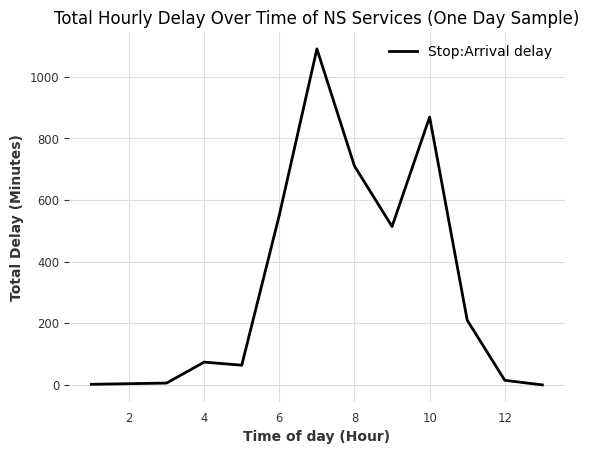

In [95]:
# Aggregate arrival delay by hour (sum of arrival delay minutes for all trains on a given hour in a day)
df_aggregated = all_data_merged.groupby('hour')['Stop:Arrival delay'].sum().reset_index()

# Create a TimeSeries from the aggregated DataFrame
total_hourly_delay_one_day = TimeSeries.from_dataframe(df_aggregated, time_col='hour', value_cols='Stop:Arrival delay')

# Plot the aggregated delay time series
total_hourly_delay_one_day.plot();
plt.title("Total Hourly Delay Over Time of NS Services (One Day Sample)")
plt.xlabel("Time of day (Hour)")
plt.ylabel("Total Delay (Minutes)")
plt.show()


# preprocess for Naive & XGB
2 rows in services for departure location and arrival location

Prediction Objectives: 
- for time horizon H (hour bin) will incoming train at station X be delayed or not?
- (regression) arrival delay

Node = stations (+ but also trains moving in between nodes? -> hetero graph)
Edge = lines (but does not represent # of rail tracks, so how to model # of lines? or just '1 shared railline')
Graph level = train railnetwork (include utilized by NS only? how? from to station data? or like jonathans official rail network (is there an alternative)?)
Master node/Context vector -> can we make a subgraph as proxy master node capturing different info than everything? maybe only large station nodes and intercity lines?


In [91]:
train_data = all_data_merged[:-5]
test_data = all_data_merged[-5:]

In [92]:
from darts.dataprocessing.transformers import StaticCovariatesTransformer

# Initialize the transformer
transformer = StaticCovariatesTransformer()

# Fit and transform the training data
train_data = transformer.fit_transform(train_data)


AttributeError: 'str' object has no attribute 'static_covariates'

In [ ]:

# Keep only relevant columns
df_sorted_agg = df_sorted[['Service:RDT-ID', 'Stop:Arrival delay', 'Stop:Arrival time']]

# Function to resample each service individually
def aggregate_5min(group, service_id):
    # Set datetime index for resampling
    group = group.set_index('Stop:Arrival time')
    # Resample to 5-minute intervals and take mean
    group_resampled = group.resample('5T').mean()
    # Forward-fill missing delays
    group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
    # Reset index to keep datetime as a column
    group_resampled = group_resampled.reset_index()
    # Add service ID back
    group_resampled['Service:RDT-ID'] = service_id
    return group_resampled

# Apply to each service
df_list = []
for service_id, group in df_sorted_agg.groupby('Service:RDT-ID'):
    df_list.append(aggregate_5min(group, service_id))

# Combine all services back into a single DataFrame
df_agg = pd.concat(df_list, ignore_index=True)

print(df_agg.head())
print(df_agg.dtypes)

C:\Users\jialo\AppData\Local\Temp\ipykernel_15028\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15028\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
C:\Users\jialo\AppData\Local\Temp\ipykernel_15028\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15028\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:A

          Stop:Arrival time  Service:RDT-ID  Stop:Arrival delay
0 2019-01-01 01:10:00+00:00          738804                 0.0
1 2019-01-01 01:15:00+00:00          738804                 0.0
2 2019-01-01 01:20:00+00:00          738804                 1.0
3 2019-01-01 01:25:00+00:00          738804                 1.0
4 2019-01-01 01:30:00+00:00          738804                 1.0
Stop:Arrival time     datetime64[ns, UTC]
Service:RDT-ID                      int64
Stop:Arrival delay                float64
dtype: object


In [68]:
split_index = int(len(df_sorted) * 0.8)
train_df = df_agg.iloc[:split_index].reset_index(drop=True)
test_df = df_agg.iloc[split_index:].reset_index(drop=True)


In [81]:
series_train = TimeSeries.from_group_dataframe(
    train_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

series_test = TimeSeries.from_group_dataframe(
    test_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\darts\timeseries.py:5145: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_times = resampled_times.asfreq(freq)
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\darts\timeseries.py:5145: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_times = resampled_times.asfreq(freq)
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-pa

In [ ]:
# Aggregate sales by date (sum of sales for all products on the same date)
#df_aggregated = series_train.groupby('Stop:Arrival time')['Stop:Arrival delay'].sum().reset_index()

# Create a TimeSeries from the aggregated DataFrame

total_delay_series = series_train
# Plot the aggregated sales
total_delay_series.plot()
plt.title("Total Arrival Delay over time")
plt.xlabel("5min Intervals")
plt.ylabel("Total Arrival Delay")
plt.show()

AttributeError: 'list' object has no attribute 'plot'

In [ ]:
from darts.models import RegressionModel
from xgboost import XGBRegressor

In [96]:
from darts.models import GlobalNaiveSeasonal, RandomForest, XGBModel, LightGBMModel
# pip install xgboost
import numpy as np
forecasts = {}

seasonality_period = 7

input_chunk_length = seasonality_period * 2
output_chunk_length = seasonality_period

random_state = 8

# rf_model = RandomForest(lags=seasonality_period, random_state = random_state)
# xgb_model = XGBModel(lags=seasonality_period, random_state = random_state)
# xgb_model = RegressionModel(lags=seasonality_period, model=XGBRegressor(objective='reg:squarederror', random_state=random_state))
# lgbm_model = LightGBMModel(lags=seasonality_period,random_state = random_state)
naive_model = GlobalNaiveSeasonal(input_chunk_length=input_chunk_length, output_chunk_length=output_chunk_length)

naive_model.fit(series_train)
# xgb_model.fit(series_train)
# lgbm_model.fit(series_train)

naive_forecast = [naive_model.predict(2, series=ts) for ts in series_train]
# xgb_forecast = [xgb_model.predict(28, series=ts) for ts in series_train]
# lgbm_forecast = [lgbm_model.predict(28, series=ts) for ts in series_train]


submission_naive = pd.DataFrame()
# submission_xgb = pd.DataFrame()
# submission_lgbm = pd.DataFrame()


for i, ts in enumerate(series_train):
    product_id = ts.static_covariates['id']

    naive_values = np.round(naive_forecast[i].values().flatten()).astype(int)
    # xgb_values = np.round(xgb_forecast[i].values().flatten()).astype(int)
    # lgbm_values = np.round(lgbm_forecast[i].values().flatten()).astype(int)

    submission_naive = pd.concat([
        submission_naive,
        pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(naive_values)}})
    ])
    # submission_xgb = pd.concat([
    #     submission_xgb,
    #     pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(xgb_values)}})
    # ])
    # submission_lgbm = pd.concat([
    #     submission_lgbm,
    #     pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(lgbm_values)}})
    # ])


submission_naive.to_csv('submission_naive.csv', index=False)
# submission_xgb.to_csv('submission_xgb.csv', index=False)
# submission_lgbm.to_csv('submission_lgbm.csv', index=False)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

RuntimeError: Numpy is not available

In [99]:
# Fit naive model
naive_model.fit(series_train)

# Forecast horizon = 2
naive_forecast = [naive_model.predict(2, series=ts) for ts in series_train]

# Build submission
submission_naive = pd.DataFrame()
for i, ts in enumerate(series_train):
    product_id = ts.static_covariates['id'][0]
    values = np.round(naive_forecast[i].values().flatten()).astype(int)
    submission_naive = pd.concat([
        submission_naive,
        pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(values)}})
    ])

submission_naive.to_csv('submission_naive.csv', index=False)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

RuntimeError: Numpy is not available

# GNN
Some graph libraries
https://pyg.org/
https://www.dgl.ai/


TODO: construct graph with either services (filtering out departure FROM station, has seperate rows) or station distances dataset?

Look further into graph construction of existing work

IDEA (master node): can we utilize subgraphs as additional Context Vector (i.e. master nodes) utilizing the station classification (making multiple subgraphs of > major stations 'type' classification, assumption is that the graph connectivity stays the same; so given a node we could utilize the nearest neighbours of these subgraphs as additional feature/signals)

Node = stations (+ but also trains moving in between nodes? -> hetero graph)
Edge = lines (but does not represent # of rail tracks, so how to model # of lines? or just '1 shared railline')
Graph level = train railnetwork (include utilized by NS only? how? from to station data? or like jonathans official rail network (is there an alternative)?)
Master node/Context vector -> can we make a subgraph as proxy master node capturing different info than everything? maybe only large station nodes and intercity lines?

# Weather data test

In [46]:

folder_path = Path("downloads/data")
stations_csv_path = os.path.join(folder_path, "NS-stations/stations-2023-09-nl.csv")
weather_parquet_path = os.path.join(folder_path, "weather-data/weather_data.parquet")

in_progress_stations = []

In [ ]:
stations_df = pd.read_csv(stations_csv_path)
stations_df.head(3)

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611


De stations in deze dataset worden gebruikt door de Rijden de Treinen website en app. De bron voor deze data is NS; de stations worden direct uit de NS API gehaald. De stationsnamen, geocoördinaten en stationcodes worden bepaald door NS.

rdt_id/id = intern RdT ID

code stationsnaam code max 8 chars, NS/prorail code

UIC code (international id station code), nl stations have 84 prefix

name_short korte station
name_medium
name_long full station name

slug = uniek small case, no space, consistent w RdT stationspage

type = Het soort station. Mogelijke waarden zijn (van groot naar klein station): megastation, knooppuntIntercitystation, intercitystation, knooppuntSneltreinstation, sneltreinstation, knooppuntStoptreinstation, stoptreinstation, facultatiefStation. De categorie knooppunt impliceert dat deze stations bedoeld zijn voor het overstappen op een andere trein. Een facultatiefStation is een station waar normaal gesproken geen treinen stoppen, behalve bij speciale gelegenheden (zoals voetbalwedstrijden).


Check the following for EDA on stations: different kind of stations
KnooppuntStation
Facultiefstation
check Knooppunt
Station coverage (i.e. which stations have the most # of trains stopping/crossing)

Check whether all stations are covered by atleast one train/service (per year?)

Filter on NL, for double check

geo_lat, latitude degree
geo_lng, longitude degree



In [9]:
stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           397 non-null    int64  
 1   code         396 non-null    object 
 2   uic          397 non-null    int64  
 3   name_short   397 non-null    object 
 4   name_medium  397 non-null    object 
 5   name_long    397 non-null    object 
 6   slug         397 non-null    object 
 7   country      397 non-null    object 
 8   type         397 non-null    object 
 9   geo_lat      397 non-null    float64
 10  geo_lng      397 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 34.2+ KB


### Stations DF

In [10]:
stations_df.describe()

,id,uic,geo_lat,geo_lng
count,397.000000,3.970000e+02,397.000000,397.000000
mean,315.503778,8.400380e+06,52.160612,5.524714
std,193.894114,2.047490e+02,0.602023,0.768896
min,5.000000,8.400045e+06,50.771946,3.595278
25%,157.000000,8.400200e+06,51.863154,4.878056
50%,304.000000,8.400362e+06,52.145279,5.573889
75%,456.000000,8.400553e+06,52.458611,6.057500
max,820.000000,8.400752e+06,53.458419,7.199370


In [11]:
stations_df.shape

(397, 11)

In [12]:
stations_df.isna().sum()

id             0
code           1
uic            0
name_short     0
name_medium    0
name_long      0
slug           0
country        0
type           0
geo_lat        0
geo_lng        0
dtype: int64

There seems to be one station code missing; 'Nieuw Amsterdam'. We leave this in for now. (We will filter stations out, probably by constructing the station network by stations utilized by NS/in operation only, TODO: check preprocessing against jonathan's, his argumentation for preprocessing and double check w ali)

In [13]:
stations_df[stations_df['code'].isna()]

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
247,349,NaN,8400454,Nw A'dam,Nw. Amsterdam,Nieuw Amsterdam,nieuw-amsterdam,NL,sneltreinstation,52.718613,6.848611


# TODO check tabular datasets and partitioning in pyarrow documentation for scalability

# TODO for eda add graph characteristics summary (edge, node, graph-level, connectivity), IC/sprinter, main stops, temp stops, features, classes etc...